In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("D:\Telco_customer_churn.xlsx")

In [4]:
df.head()



,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe()



,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
df.shape

(7043, 33)

In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Feature Engineering

In [11]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [12]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [13]:
drop_cols = [
    'CustomerID',
    'Count',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Zip Code'
]

df = df.drop(columns=drop_cols)

In [14]:
df.columns

Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Reason'],
      dtype='object')

In [15]:
df['Revenue Segment'] = pd.cut(
    df['Monthly Charges'],
    bins=[0,50,100,150],
    labels=['Low','Medium','High']
)

In [16]:
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0,12,24,48,72],
    labels=['0-1 Year',
            '1-2 Years',
            '2-4 Years',
            '4-6 Years']
)

In [17]:
# Exploratory Data Analysis EDA


In [18]:
# What percentage of customers leave?

<Axes: xlabel='Churn Label', ylabel='count'>

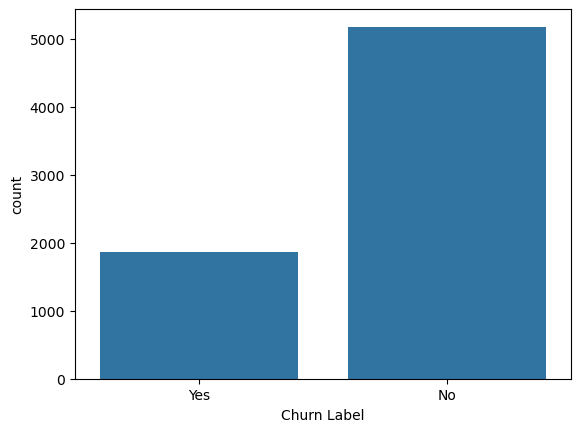

In [19]:
sns.countplot(
    x='Churn Label',
    data=df
)

<Axes: xlabel='Gender', ylabel='count'>

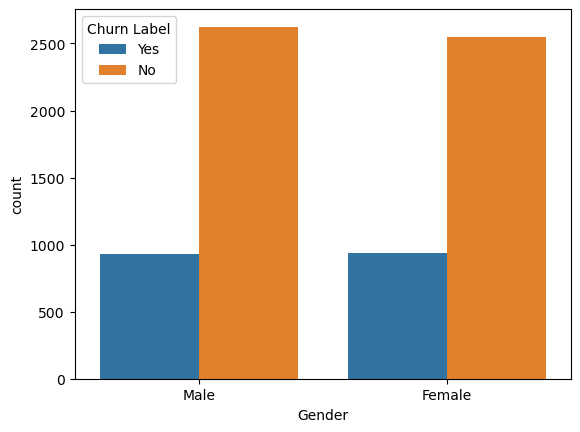

In [20]:
sns.countplot(
    x='Gender',
    hue='Churn Label',
    data=df
)

<Axes: xlabel='Senior Citizen', ylabel='count'>

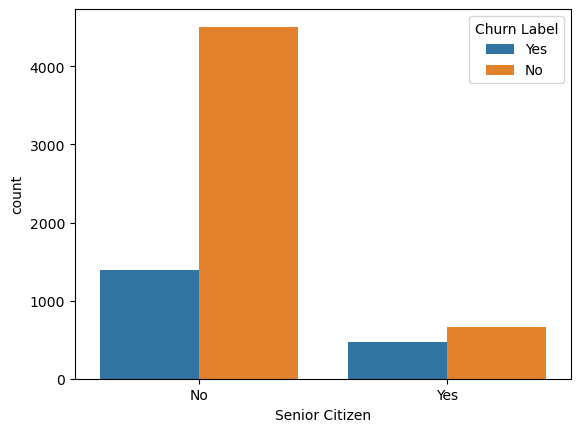

In [21]:
sns.countplot(
    x='Senior Citizen',
    hue='Churn Label',
    data=df
)

<Axes: xlabel='Contract', ylabel='count'>

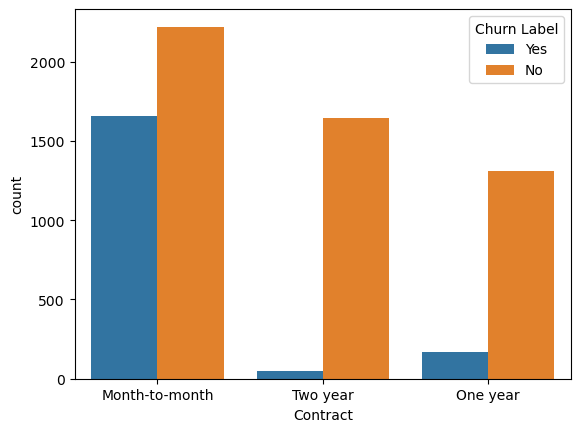

In [22]:
sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

<Axes: xlabel='Internet Service', ylabel='count'>

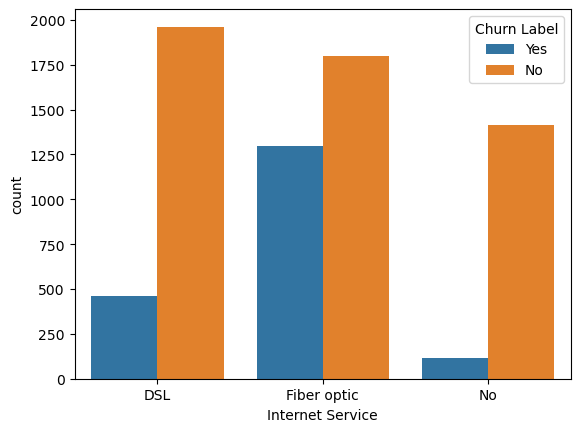

In [23]:
sns.countplot(
    x='Internet Service',
    hue='Churn Label',
    data=df
)

([0, 1, 2, 3],
 [Text(0, 0, 'Mailed check'),
  Text(1, 0, 'Electronic check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

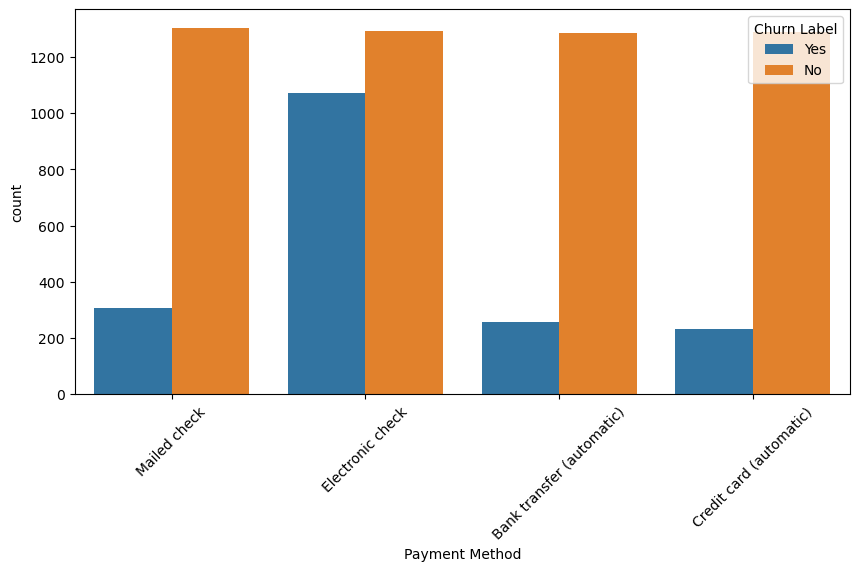

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df
)

plt.xticks(rotation=45)

<Axes: xlabel='Churn Label', ylabel='Monthly Charges'>

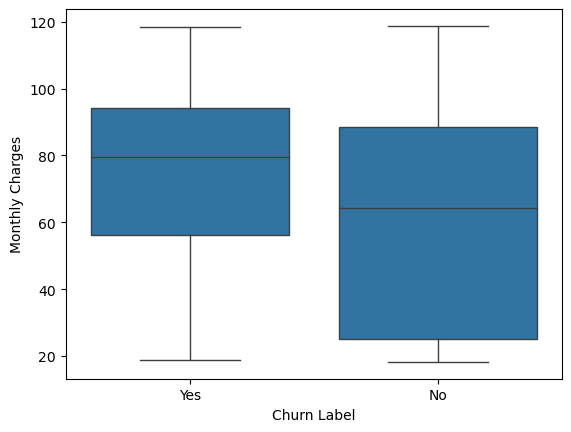

In [25]:
sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

<Axes: xlabel='Churn Label', ylabel='Total Charges'>

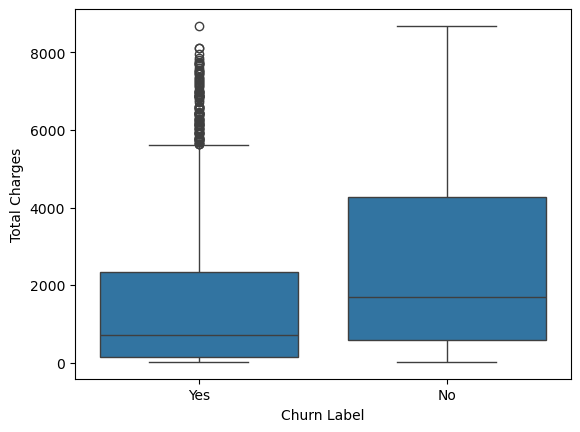

In [26]:
sns.boxplot(
    x='Churn Label',
    y='Total Charges',
    data=df
)

<Axes: xlabel='Churn Label', ylabel='Tenure Months'>

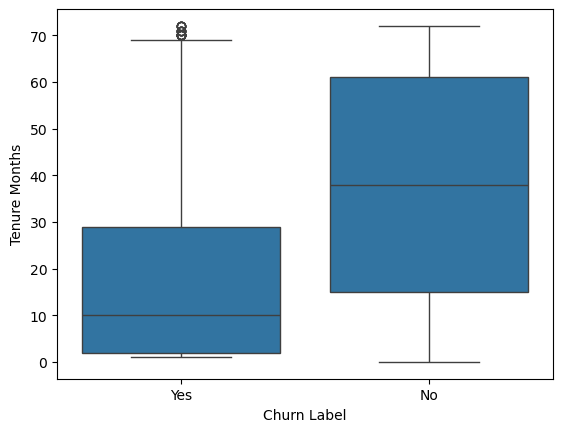

In [27]:
sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)

<Axes: xlabel='Churn Label', ylabel='CLTV'>

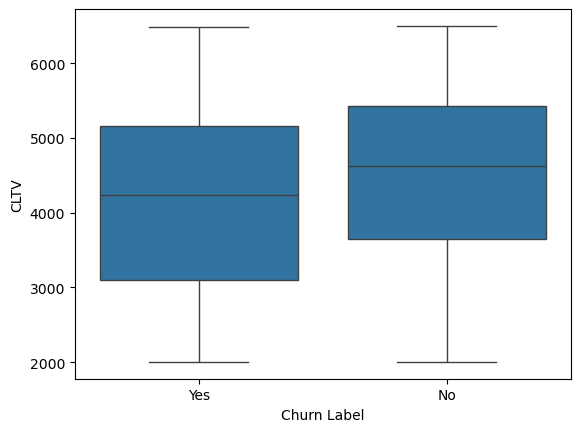

In [28]:
sns.boxplot(
    x='Churn Label',
    y='CLTV',
    data=df
)

In [29]:
df['Churn Reason'].value_counts().head(10)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

<Axes: xlabel='Churn Reason'>

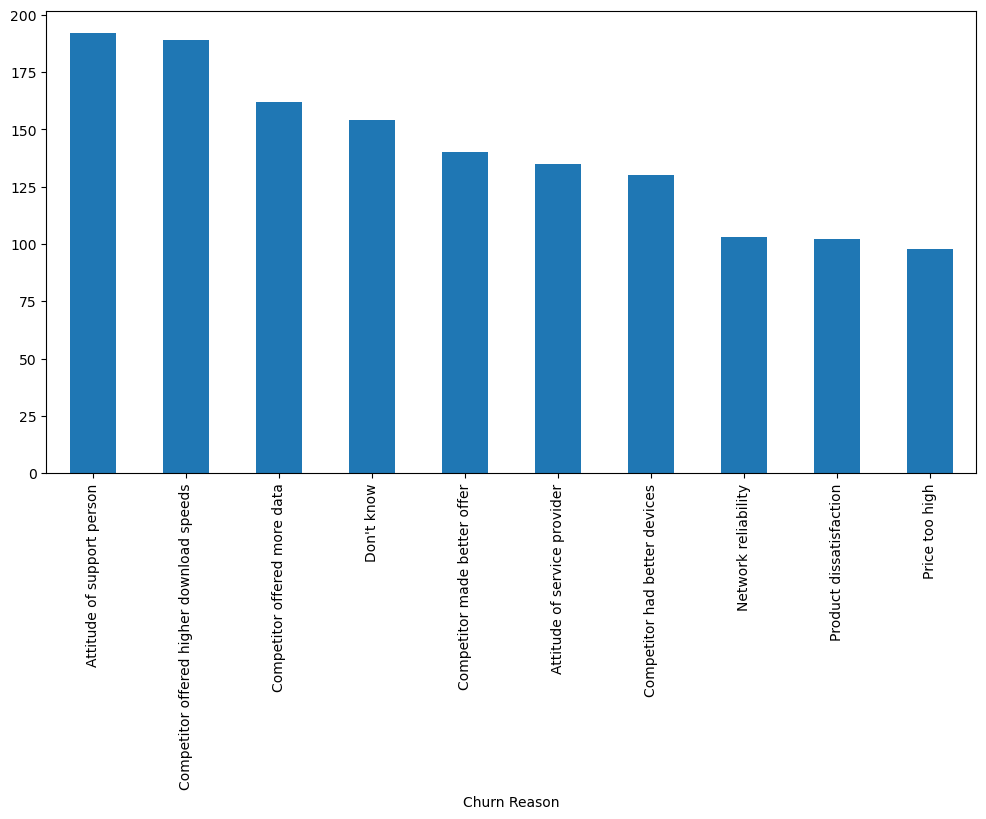

In [30]:
plt.figure(figsize=(12,6))

df['Churn Reason'].value_counts().head(10).plot(kind='bar')

In [31]:
state_churn = df.groupby('State')['Churn Value'].mean()

state_churn.sort_values(
    ascending=False
).head(10)

State
California    0.26537
Name: Churn Value, dtype: float64

In [32]:
city_churn = df.groupby('City')['Churn Value'].mean()

city_churn.sort_values(
    ascending=False
).head(10)

City
Fort Jones       1.0
Eldridge         1.0
Maricopa         1.0
Boulder Creek    1.0
Riverbank        1.0
Twain            1.0
Johannesburg     1.0
Smith River      1.0
Tipton           1.0
Wrightwood       1.0
Name: Churn Value, dtype: float64

In [33]:
!pip install sqlalchemy psycopg2-binary

In [34]:
from sqlalchemy import create_engine
import psycopg2

In [35]:
username = "postgres"
password = "12345678"
host = "localhost"
port = "5432"
database = "customer_churn"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("Connected Successfully!")

Connected Successfully!


In [36]:
df.to_sql(
    name="telecom_churn",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")


Data uploaded successfully!


In [38]:
df.columns

Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Reason', 'Revenue Segment', 'Tenure Group'],
      dtype='object')

In [41]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

(df.columns)

Index(['country', 'state', 'city', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure_months', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv',
       'churn_reason', 'revenue_segment', 'tenure_group'],
      dtype='object')

In [69]:
# Save cleaned dataset
df.to_csv("telecom_churn_clean.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [70]:
drop_cols = [
    "country",
    "state",
    "city",
    "churn_label",      # duplicate of target
    "churn_score",      # target leakage
    "churn_reason"      # target leakage
]

df_ml = df.drop(columns=drop_cols)

In [71]:


from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from joblib import dump

In [72]:
df = pd.read_csv("telecom_churn_clean.csv")

df.head()

,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,...,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,revenue_segment,tenure_group
0,United States,California,Los Angeles,Male,No,No,No,2,Yes,No,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Medium,0-1 Year
1,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,No,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Medium,0-1 Year
2,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,Yes,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,Medium,0-1 Year
3,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,High,2-4 Years
4,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,Yes,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,High,4-6 Years


In [73]:
drop_cols = [

    "country",
    "state",
    "city",

    "churn_label",
    "churn_score",
    "churn_reason"

]

df_ml = df.drop(columns=drop_cols)

df_ml.head()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,cltv,revenue_segment,tenure_group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,Medium,0-1 Year
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,Medium,0-1 Year
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,Medium,0-1 Year
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,High,2-4 Years
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,High,4-6 Years


In [74]:
df_ml.isnull().sum()

gender                0
senior_citizen        0
partner               0
dependents            0
tenure_months         0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn_value           0
cltv                  0
revenue_segment       0
tenure_group         11
dtype: int64

In [75]:
num_cols = df_ml.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:

    df_ml[col] = df_ml[col].fillna(df_ml[col].median())

In [76]:
cat_cols = df_ml.select_dtypes(include="object").columns

for col in cat_cols:

    df_ml[col] = df_ml[col].fillna(df_ml[col].mode()[0])

In [77]:
X = df_ml.drop("churn_value", axis=1)

y = df_ml["churn_value"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [79]:
categorical_features = X.select_dtypes(include="object").columns

numeric_features = X.select_dtypes(exclude="object").columns

print(categorical_features)

print(numeric_features)

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'revenue_segment', 'tenure_group'],
      dtype='object')
Index(['tenure_months', 'monthly_charges', 'total_charges', 'cltv'], dtype='object')


In [80]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(handle_unknown="ignore"),

            categorical_features

        ),

        (

            "num",

            StandardScaler(),

            numeric_features

        )

    ]

)

In [81]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [82]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("classifier", model)

    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob)

    })

In [83]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.799858,0.643750,0.550802,0.593660,0.848813
2,Random Forest,0.786373,0.622074,0.497326,0.552749,0.839769
3,XGBoost,0.792761,0.626543,0.542781,0.581662,0.834464
1,Decision Tree,0.718240,0.470588,0.491979,0.481046,0.645989


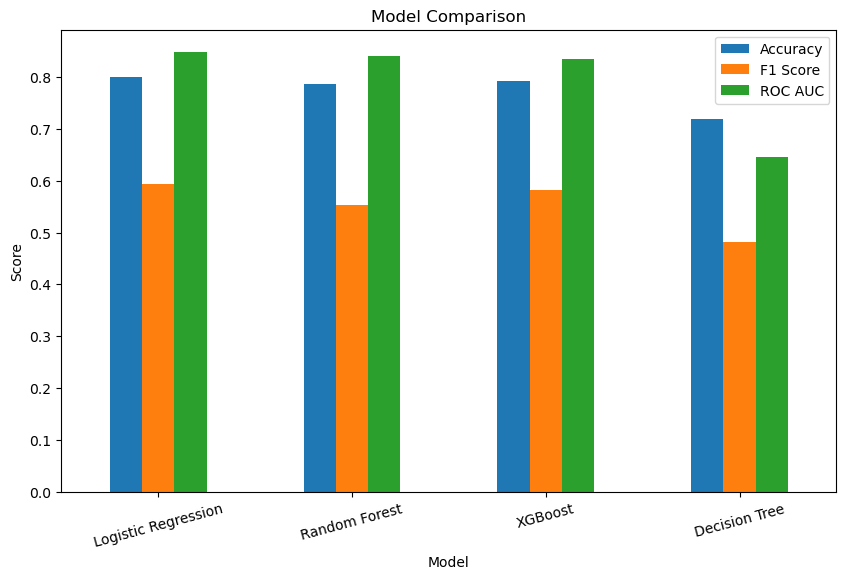

In [84]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy","F1 Score","ROC AUC"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

In [85]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

best_pipeline = trained_models[best_model_name]

Best Model: Logistic Regression


In [86]:
y_pred = best_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



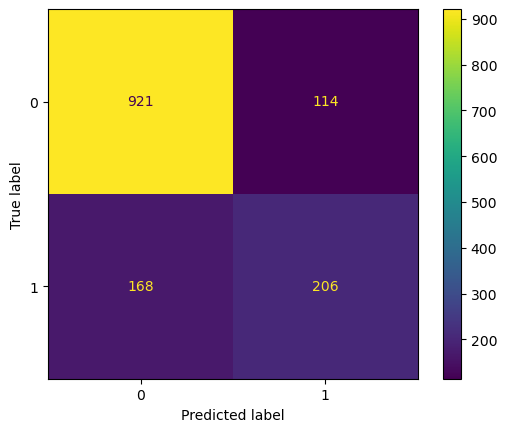

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [88]:
y_prob = best_pipeline.predict_proba(X_test)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

ROC AUC: 0.8488129375597407


In [89]:
from joblib import dump

dump(
    best_pipeline,
    "customer_churn_pipeline.pkl"
)

['customer_churn_pipeline.pkl']

In [90]:
from joblib import load

model = load("customer_churn_pipeline.pkl")

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

probability = model.predict_proba(sample)

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [0]
Probability: [[0.9288312 0.0711688]]


In [91]:
print(type(model))

print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'revenue_segment', 'tenure_group'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['tenure_months', 'monthly_charges', 'total_charges', 'cltv'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])
